In [1]:
!unzip -o "./Custom Workflow Instance Segmentation.v1i.yolov8-obb.zip" -d yolo_dataset

Archive:  ./Custom Workflow Instance Segmentation.v1i.yolov8-obb.zip
  inflating: yolo_dataset/README.dataset.txt  
  inflating: yolo_dataset/README.roboflow.txt  
  inflating: yolo_dataset/data.yaml  
   creating: yolo_dataset/test/
   creating: yolo_dataset/test/images/
 extracting: yolo_dataset/test/images/Oil_0005_jpg.rf.6e1675575fb81a231a00db2790012c6d.jpg  
 extracting: yolo_dataset/test/images/Oil_0038_jpg.rf.9602ea5f7046cbbd8a9ee5f43ba375bc.jpg  
 extracting: yolo_dataset/test/images/Oil_0044_jpg.rf.6bd79d687c2b079a29155c1aa82b9bf7.jpg  
 extracting: yolo_dataset/test/images/Oil_0050_jpg.rf.894cd85dc54eb2fe4ccdca3967817abe.jpg  
 extracting: yolo_dataset/test/images/Oil_0051_jpg.rf.7893264bb6b96b8ad16fddf3f28b0456.jpg  
 extracting: yolo_dataset/test/images/Oil_0052_jpg.rf.cf03447d2645720553353074790aedce.jpg  
 extracting: yolo_dataset/test/images/Oil_0072_jpg.rf.816fd2d68b2602b0ff469023b9fc635a.jpg  
 extracting: yolo_dataset/test/images/Oil_0104_jpg.rf.16f63232052de88c0ad446

In [2]:
!pip install ultralytics

from ultralytics import YOLO

# 모델 로드: 커스텀 학습을 위한 사전 학습된 YOLOv8 모델
model = YOLO('yolov8n.pt')  # 'n'=nano, 's', 'm', 'l'도 가능

# 학습 실행
model.train(
    data='./yolo_dataset/data.yaml',  # 데이터 경로 (Colab 기준)
    epochs=30,
    imgsz=640,
    batch=16,
    name='yolo_display_defect',
    task='detect'  # 또는 'segment' 등 Roboflow 구조에 맞게
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ef4421048c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 


image 1/1 /content/yolo_dataset/test/images/Scr_0035_jpg.rf.488081093ce67a774daa52a25333fef7.jpg: 640x640 2 --s, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


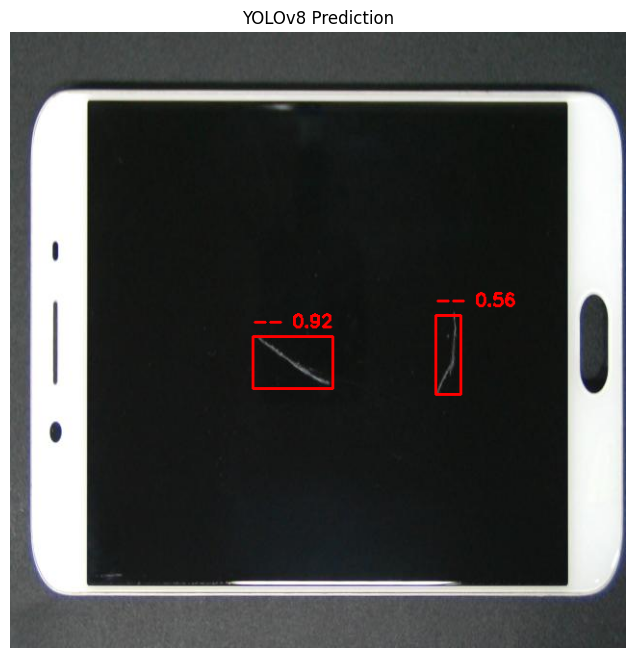

In [3]:
!pip install ultralytics
from ultralytics import YOLO

# 훈련된 모델 로드
model = YOLO('runs/detect/yolo_display_defect/weights/best.pt')  # 학습된 모델 경로

import cv2
import matplotlib.pyplot as plt

# 이미지 경로 지정
img_path = 'yolo_dataset/test/images/Scr_0035_jpg.rf.488081093ce67a774daa52a25333fef7.jpg'

# 예측
results = model(img_path)

# 시각화용 이미지 불러오기
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 결과 객체에서 바운딩 박스 그리기
for r in results:
    boxes = r.boxes  # 바운딩 박스 정보
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # 좌표
        cls_id = int(box.cls[0])  # 클래스 ID
        conf = float(box.conf[0])  # 신뢰도
        label = f"{model.names[cls_id]} {conf:.2f}"

        # 박스와 라벨 그리기
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title("YOLOv8 Prediction")
plt.show()